In [2]:
import zipfile

with zipfile.ZipFile('/content/house-prices-advanced-regression-techniques (2).zip', 'r') as zip_ref:
    zip_ref.extractall('house_data')

print("Extracted Successfully!")

Extracted Successfully!


In [3]:
import os

print(os.listdir('house_data'))

['house-prices-advanced-regression-techniques.zip']


In [6]:
!unzip -o "/content/house-prices-advanced-regression-techniques (2).zip" -d house_data

Archive:  /content/house-prices-advanced-regression-techniques (2).zip
  inflating: house_data/house-prices-advanced-regression-techniques.zip  


In [7]:
import os
print(os.listdir("house_data"))

['house-prices-advanced-regression-techniques.zip']


In [9]:
!unzip -o "/content/house_data/house-prices-advanced-regression-techniques.zip" -d house_data

Archive:  /content/house_data/house-prices-advanced-regression-techniques.zip
  inflating: house_data/data_description.txt  
  inflating: house_data/sample_submission.csv  
  inflating: house_data/test.csv     
  inflating: house_data/train.csv    


In [10]:
import pandas as pd

df = pd.read_csv("house_data/train.csv")

print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


MAE : 35788.061292436294
MSE : 2806426667.247853
R2 Score : 0.6341189942328371


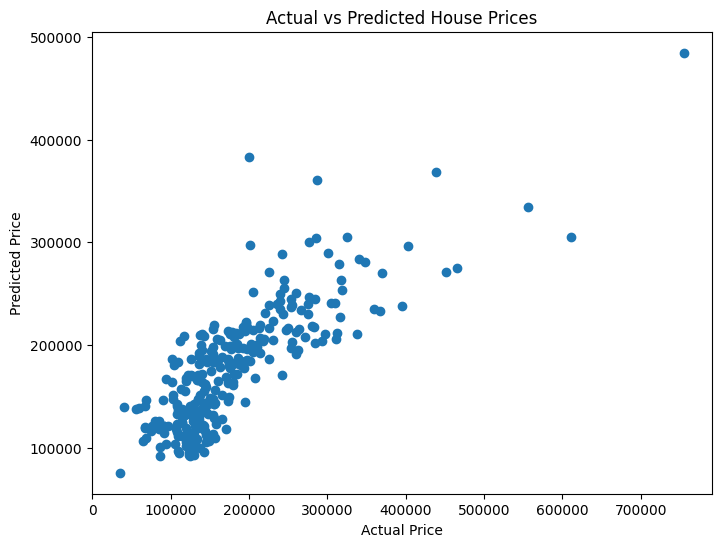

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
df = pd.read_csv("house_data/train.csv")

# Features
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]

# Target
y = df['SalePrice']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))

# Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()